## V) Find the Roots of a Polynomial Algebraically or Numerically
Use SymPy to find the roots of a univariate polynomial algebraically. 
Alternatives to Consider - If you need a numeric (rather than algebraic) solution, you can use either
NumPy’s roots()
SciPy’s root()
If you need to solve systems of polynomial equations algebraically, use solve()

In [2]:
import sympy 
from sympy import roots
from sympy.abc import x, a, b, c
sympy.init_printing() # initializethe best printing format
roots(a*x**2 + b*x + c, x) # This example reproduces the quadratic formula.

ModuleNotFoundError: No module named 'sympy'

Functions to Find the Roots of a Polynomial
* solve() is a general solving function which can find roots, though is less efficient than all_roots() and is the only function in this list that does not convey the multiplicity of roots; solve() also works on non-polynomial equations and systems of non-polynomial equations
roots() computes the symbolic roots of a univariate polynomial; will fail for most high-degree polynomials (five or greater)
* nroots() computes numerical approximations of the roots of any polynomial whose coefficients can be numerically evaluated, whether the coefficients are rational or irrational
* RootOf() can represent all the roots exactly of a polynomial of arbitrarily large degree, as long as the coefficients are rational numbers. RootOf() can avoid both ill-conditioning and returning spurious complex parts because it uses a more exact, but much slower, numerical algorithm based on isolating intervals. The following two functions use RootOf() so they have the same properties:
        - real_roots() can find all the real roots exactly of a polynomial of arbitrarily large degree; because it finds only the real roots, it can be more efficient than functions that find all roots.
        - all_roots() can find all the roots exactly of a polynomial of arbitrarily large degree
* factor() factors a polynomial into irreducibles and can reveal that roots lie in the coefficient ring

Guidance - Refer to Include the Variable to be Solved for in the Function Call and Use Exact Values.

Find the Roots of a Polynomial algebraically in several ways, depending on whether you:
* want an algebraic or numeric answer
* want the multiplicity of each root (how many times each root is a solution). In the expression below representing (x-2)^2 * (x-3) , the root -2 has a multiplicity of two because x-2 is squared, whereas 3 has a multiplicity of one because x-3  has no exponent. Similarly, for the symbolic expression, the root -a has a multiplicity of two and the root b has a multiplicity of one.

In [26]:
from sympy import solve, roots, real_roots, factor, nroots, RootOf, expand
from sympy.abc import x, a, b, c
from sympy import Poly
expression = (x+2)**2 * (x-3)
symbolic = (x+a)**2 * (x-b)
expression
symbolic

Algebraic Solution Without Root Multiplicities - 
You can use SymPy’s standard solve() function, though it will not return the multiplicity of roots:

In [6]:
solve(expression, x, dict=True)

In [7]:
solve(symbolic, x, dict=True)

solve() will first try using roots(); if that doesn’t work, it will try using all_roots(). For cubics (third-degree polynomials) and quartics (fourth-degree polynomials), that means that solve() will use radical formulae from roots rather than RootOf() even if RootOf is possible. The cubic and quartic formulae often give very complex expressions that are not useful in practice. As a result, you may want to set the solve() parameter cubics or quartics to False to return RootOf() results:

In [ ]:
from sympy import solve
from sympy.abc import x
# By default, solve() uses the radical formula, yielding very complex terms
solve(x**4 - x + 1, x)

In [ ]:
# If you set quartics=False, solve() uses RootOf()
solve(x**4 - x + 1, x, quartics=False)
# Writing the first root from solve() in standard mathematical notation emphasizes how complex it is:

Further, there is no general radical formula for quintics (fifth degree) or higher polynomials, so their RootOf() representations may be the best option.

Algebraic Solution With Root Multiplicities
roots() can give explicit expressions for the roots of polynomials that have symbolic coefficients (that is, if there are symbols in the coefficients) if factor() does not reveal them. However, it may fail for some polynomials. Here are examples of roots():

In [ ]:
roots(expression, x)
# It returns results as a dictionary, where the key is the root (for example, -2) and the value is the multiplicity of that root (for example, 2).

In [ ]:
roots(symbolic, x)
# roots() function uses a combination of techniques (factorization, decomposition, 
# radical formulae) to find expressions in radicals if possible for the roots. 
# When it can find some radical expressions for the roots, it returns them along 
# with their multiplicity. This function will fail for most high-degree polynomials
#  (five or greater) because they do not have radical solutions, and there is 
# no guarantee that they have closed-form solutions at all, as explained by the 
# Abel-Ruffini theorem.

Factor the Equation
A different approach is to factor a polynomial using factor(), which does not give the roots directly but can give you simpler expressions:

In [27]:

expression_expanded = expand(expression)
expression_expanded

In [5]:
factor(expression_expanded)

(x - 3)*(x + 2)**2

In [28]:
symbolic_expanded = expand(symbolic)
symbolic_expanded

In [7]:
factor(symbolic_expanded)

(a + x)**2*(-b + x)

factor() can also factorize a polynomial in a given polynomial ring which can reveal roots lie in the coefficient ring. For example, if the polynomial has rational coefficients, then factor() will reveal any rational roots. If the coefficients are polynomials involving, for example, symbol  with rational coefficients then any roots that are polynomial functions of  with rational coefficients will be revealed. In this example, factor() reveals that  and  are roots:

In [2]:

from sympy import expand, factor
from sympy.abc import x, a
p = expand((x - a**2)*(x + a + a**3))
p

-a**5 + a**3*x - a**3 - a**2*x + a*x + x**2

In [3]:
factor(p)

(-a**2 + x)*(a**3 + a + x)

Exact Numeric Solution With Root Multiplicities
If the roots to your polynomial are real, using real_roots() ensures that only real (not complex or imaginary) roots will be returned.

In [3]:
from sympy import real_roots
from sympy.abc import x
cubed = x**3 - 1
cubed

In [4]:
import sympy 
from sympy import solve, roots, real_roots, factor, nroots, RootOf, expand
sympy.init_printing() # initializethe best printing format
# roots() returns real and complex roots
roots(cubed)

In [11]:
# real_roots() returns only real roots
real_roots(cubed)

In [14]:
# real_roots() calls RootOf(), so for equations whose roots are all real, you can get the same results by iterating over the number of roots of your equation:
expression = (x+2)**2 * (x-3)
symbolic = (x+a)**2 * (x-b)
[RootOf(expression, n) for n in range(3)]

Approximate Numeric Solution With Root Multiplicities
nroots() gives an approximate numerical approximation to the roots of a polynomial. This example demonstrates that it can include numerical noise, for example a (negligible) imaginary component in what should be a real root:

In [15]:
nroots(expression)

If you want numeric approximations of the real roots, but you want to know exactly which roots are real, then the best method is real_roots() with evalf():

In [19]:
[r.n(2) for r in real_roots(expression)]

In [18]:
[r.is_real for r in real_roots(expression)]

[True, True, True]

nroots() is analogous to NumPy’s roots() function. Usually the difference between these two is that nroots() is more accurate but slower.

A major advantage of nroots() is that it can compute numerical approximations of the roots of any polynomial whose coefficients can be numerically evaluated with evalf() (that is, they do not have free symbols). Contrarily, symbolic solutions may not be possible for higher-order (fifth or greater) polynomials as explained by the Abel-Ruffini theorem. Even if closed-form solutions are available, they may have so many terms that they are not useful in practice. You may therefore want to use nroots() to find approximate numeric solutions even if closed-form symbolic solutions are available. For example, the closed-form roots of a fourth-order (quartic) polynomial may be rather complicated:

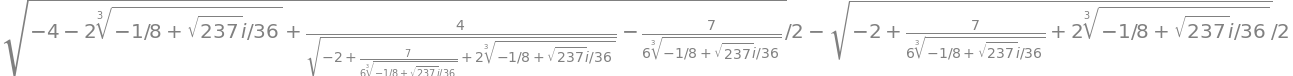

In [5]:
rq0, rq1, rq2, rq3 = roots(x**4 + 3*x**2 + 2*x + 1)
rq0

so you may prefer an approximate numerical solution:

In [6]:
# so you may prefer an approximate numerical solution:
rq0.n()

nroots() can fail sometimes for polynomials that are numerically ill conditioned, for example Wilkinson’s polynomial. Using RootOf() and evalf() as described in Numerically Evaluate CRootOf Roots can avoid both ill-conditioning and returning spurious complex parts because it uses a more exact, but much slower, numerical algorithm based on isolating intervals.

Complex Roots
For complex roots, similar functions can be used, for example solve():

In [18]:
from sympy import solve, roots, nroots, real_roots, expand, RootOf, CRootOf, Symbol
from sympy import Poly
from sympy.abc import x
expression_complex = (x**2+4)**2 * (x-3)
# solve(expression_complex, x, dict=True)
expression_complex

In [9]:
solve(expression_complex, x, dict=True)

If the constants are symbolic, you may need to specify their domain for SymPy to recognize that the solutions are not real. For example, specifying that  is positive leads to imaginary roots:

In [11]:
a = Symbol("a", positive=True)
symbolic_complex = (x**2+a)**2 * (x-3)
symbolic_complex

In [12]:
solve(symbolic_complex, x, dict=True)

In [13]:
# roots() will also find imaginary or complex roots:
roots(expression_complex, x)

In [14]:
# RootOf() will also return complex roots:
[RootOf(expression_complex, n) for n in range(0,3)]

In [15]:
# real_roots() will return only the real roots.
real_roots(expression_complex)

An advantage of real_roots() is that it can be more efficient than generating all the roots: RootOf() can be slow for complex roots.

If you make the expression into a polynomial class Poly, you can use its all_roots() method to find the roots:

In [16]:
expression_complex_poly = Poly(expression_complex)
expression_complex_poly.all_roots()

Use the Solution Result - The way to extract solutions from the result depends on the form of the result.

List (all_roots, real_roots, nroots)
You can use standard Python list traversal techniques such as looping. Here, we substitute each root into the expression to verify that the result is :

In [17]:
expression = (x+2)**2 * (x-3)
my_real_roots = real_roots(expression)
my_real_roots

In [19]:
for root in my_real_roots:
        print(f"expression({root}) = {expression.subs(x, root)}")

expression(-2) = 0
expression(-2) = 0
expression(3) = 0


List of dictionaries (solve) - Refer to Use the Solution Result.Dictionary (roots)

You can use standard Python list traversal techniques such as looping through the keys and values in a dictionary. Here we print the value and multiplicity of each root:

In [22]:
my_roots = roots(expression)
my_roots

In [23]:
for root, multiplicity in my_roots.items():
    print(f"Root {root} has multiplicity of {multiplicity}")

Root 3 has multiplicity of 1
Root -2 has multiplicity of 2


Expression (factor)
You can manipulate an algebraic expression using various SymPy techniques, for example substituting in a symbolic or numeric value for :

In [29]:
from sympy.abc import y
factored = factor(expression_expanded)
factored

In [30]:
factored.subs(x, 2*y)

In [31]:
factored.subs(x, 7)

Tradeoffs
Mathematical Exactness, Completeness of List of Roots, and Speed
Consider the high-order polynomial . nroots() returns numerical approximations to all five roots:

In [4]:
from sympy import roots, solve, real_roots, nroots
from sympy.abc import x
from sympy import init_printing
init_printing() # initializethe best printing format
fifth_order = x**5 - x + 1
nroots(fifth_order)

In [5]:
# roots() can sometimes return only a subset of the roots or nothing if it can’t express any roots in radicals. In this case, it returns no roots (an empty set):

roots(fifth_order, x)

In [ ]:
# But if you set the flag strict=True, roots() will inform you that all roots cannot be returned:

roots(x**5 - x + 1, x, strict=True)
# UnsolvableFactorError: Strict mode: some factors cannot be solved in radicals...

Get All Roots, Perhaps Implicitly
solve() will return all five roots as CRootOf (ComplexRootOf()) class members:

In [ ]:
fifth_order_solved = solve(fifth_order, x, dict=True)
fifth_order_solved
#  where the second argument in each CRootOf is the index of the root.

In [8]:
# You can then numerically evaluate those CRootOf roots using n from evalf():

for root in fifth_order_solved:
    print(root[x].n(10))

-1.167303978
-0.1812324445 - 1.083954101*I
-0.1812324445 + 1.083954101*I
0.7648844336 - 0.352471546*I
0.7648844336 + 0.352471546*I


In [12]:
# If you are only interested in the sole real root, it is faster to use real_roots() because it will not attempt to find the complex roots:

real_root = real_roots(fifth_order, x)
real_root

In [13]:
real_root[0].n(10)

Representing Roots
RootOf(), real_roots(), and all_roots() can find all the roots exactly of a polynomial of arbitrarily large degree despite the Abel-Ruffini theorem. Those functions allow the roots to be categorized precisely and manipulated symbolically.

In [16]:
from sympy import init_printing, poly
init_printing()
real_roots(fifth_order)

In [20]:
from sympy import Poly
r = r0, r1, r2, r3, r4 = Poly(fifth_order, x).all_roots(); r

Now that the roots have been found exactly, their properties can be determined free of numerical noise. For example, we can tell whether roots are real or not. If we request the conjugate() (same real part and imaginary part with opposite sign) of a root, for example r1, and that is exactly equal to another root r2, that root r2 will be returned:

In [21]:
r0.n()

In [22]:
r0.is_real

True

In [23]:

r1.n()

In [24]:
r2.n()

In [25]:
r1

In [26]:
r1.conjugate()

In [27]:
r1.is_real

False

solve() will also give the complex roots where possible but it is less efficient than using all_roots() directly.

RootOf() exactly represents the root in a way that can be manipulated symbolically, and computed to arbitrary precision. The RootOf() representation makes it possible to precisely:

Compute all roots of a polynomial with exact rational coefficients.
Decide exactly the multiplicity of every root.
Determine exactly whether roots are real or not.
Order the real and complex roots precisely.
Know which roots are complex conjugate pairs of each other.
Determine precisely which roots are rational vs irrational.
Represent every possible algebraic number exactly.
The other numerical methods such NumPy’s roots(), nroots(), and nsolve() cannot do any of these things robustly, if at all. Similarly, when numerically evaluated using evalf(), the radical expressions returned by solve() or roots() cannot do these things robustly.

Not All Equations Can Be Solved
Equations With No Closed-Form Solution
As mentioned above, higher-order polynomials (fifth or greater) are unlikely to have closed-form solutions, so you may have to represent them using, for example, RootOf as described above, or use a numerical method such as nroots as described above.